# Single tx dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def load_data(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    # Basic sanity checks
    expected_cols = {"metapath", "difference"}
    if not expected_cols.issubset(df.columns):
        raise ValueError(
            f"CSV must contain columns {expected_cols}, found {set(df.columns)}"
        )

    # Ensure 'difference' is numeric
    df["difference"] = pd.to_numeric(df["difference"], errors="coerce")
    if df["difference"].isna().any():
        n_bad = df["difference"].isna().sum()
        print(f"Warning: {n_bad} row(s) had non-numeric 'difference' values and were dropped.")
        df = df.dropna(subset=["difference"])

    return df

df = load_data("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-single-internaltx-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/dme_report.csv")
df["abs_difference"] = df["difference"].abs()

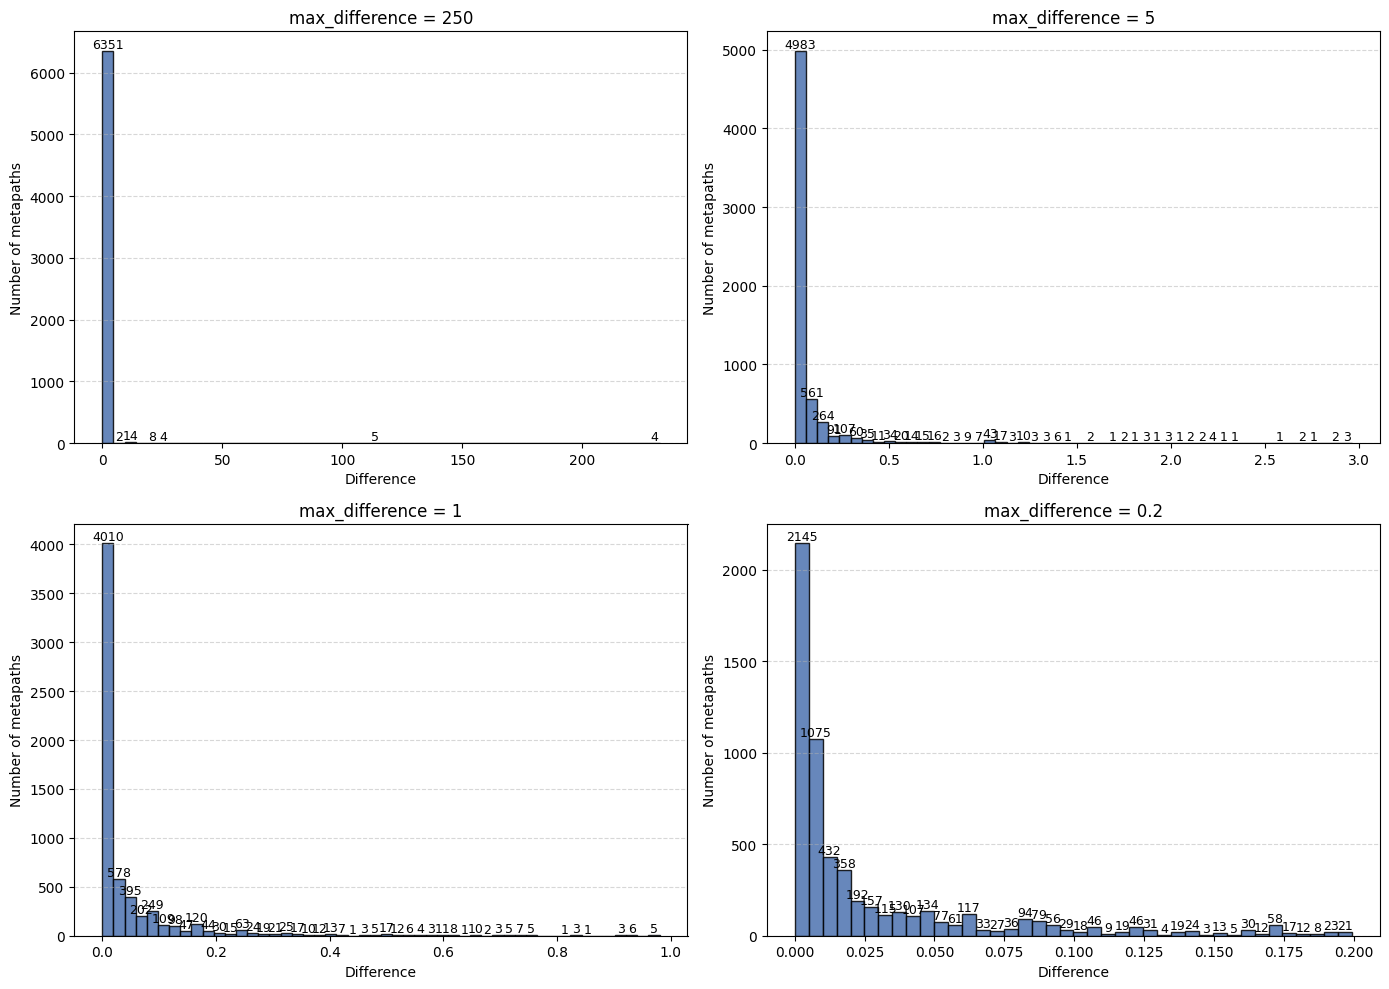

In [2]:
def plot_histogram(df: pd.DataFrame, bins: int, max_difference: float, interval_size: float = None, ax=None, ax_index: int = 0):
    """
    Plot histogram of abs_difference up to max_difference.
    If `interval_size` is provided, bins are calculated as max_difference / interval_size.
    Otherwise, uses the provided bins argument.
    If `ax` is None a new figure/axis is created.
    If `ax` is an array-like of axes (or a numpy.ndarray) the axis at ax_index is used.
    """
    # choose axis
    if ax is None:
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(1, 1, 1)
    else:
        # handle numpy.ndarray, list, tuple, or similar containers of Axes
        try:
            # numpy.ndarray has flatten(); use it if available
            if hasattr(ax, "flatten"):
                ax = ax.flatten()[ax_index]
            else:
                ax = ax[ax_index]
        except Exception:
            # if ax is already a single Axes object, leave it
            pass

    # Calculate bins based on interval_size if provided
    if interval_size is not None:
        bins = max(1, int(max_difference / interval_size))

    filtered_df = df[df["abs_difference"] <= max_difference]
    ax.hist(
        filtered_df["abs_difference"],
        bins=bins,
        color="#4C72B0",
        edgecolor="black",
        alpha=0.85,
    )

    ax.set_xlabel("Difference")
    ax.set_ylabel("Number of metapaths")
    ax.set_title(f"max_difference = {max_difference}")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Annotate bar counts above each bin
    counts, bin_edges = np.histogram(
        filtered_df["abs_difference"],
        bins=bins,
    )
    for count, left_edge, right_edge in zip(counts, bin_edges[:-1], bin_edges[1:]):
        if count > 0:
            ax.text(
                (left_edge + right_edge) / 2,
                count,
                int(count),
                ha="center",
                va="bottom",
                fontsize=9,
            )

    plt.tight_layout()
    return ax

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
plot_histogram(df, 50, 250, ax=ax, ax_index=0, interval_size=5)
plot_histogram(df, 50, 5, ax=ax, ax_index=1, interval_size=0.1)
plot_histogram(df, 50, 1, ax=ax, ax_index=2, interval_size=0.02)
plot_histogram(df, 50, 0.2, ax=ax, ax_index=3, interval_size=0.005)
plt.tight_layout()

<module 'matplotlib.pyplot' from '/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/.venv/lib/python3.14/site-packages/matplotlib/pyplot.py'>

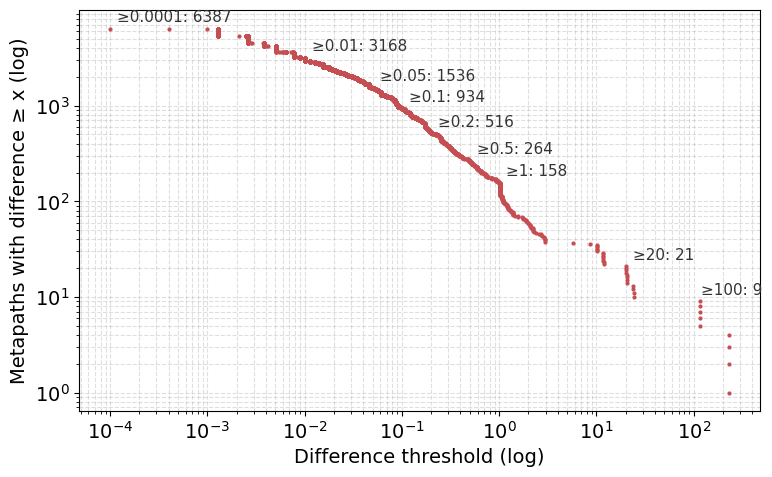

In [3]:
def compute_ccdf(values: np.ndarray):
    """Return (sorted_values, ccdf) where ccdf[i] = count of values >= sorted_values[i]."""
    sorted_vals = np.sort(values)[::-1]  # descending
    n = len(sorted_vals)
    ccdf_counts = np.arange(1, n + 1)  # rank of each value when sorted descending
    return sorted_vals, ccdf_counts
 
 
def plot_ccdf(dfs: dict[str, pd.DataFrame], thresholds: list, colors: dict[str, str] = None):
    default_colors = ["#C44E52", "#4C72B0", "#55A868", "#8172B3", "#CCB974", "#64B5CD"]
    if colors is None:
        colors = {label: default_colors[i % len(default_colors)] for i, label in enumerate(dfs)}

    plt.rcParams.update({'font.size': 14})
    fig, ax = plt.subplots(figsize=(8, 5))

    for i, (label, df) in enumerate(dfs.items()):
        values = df["abs_difference"].to_numpy()
        sorted_vals, ccdf_counts = compute_ccdf(values)
        ax.plot(sorted_vals, ccdf_counts, marker=".", linestyle="none", markersize=4, color=colors[label], label=label)
 
        for t in thresholds:
            count_ge_t = int((sorted_vals >= t).sum())
            if count_ge_t > 0:
                ax.annotate(
                    f"\u2265{t}: {count_ge_t}",
                    xy=(t, count_ge_t),
                    xytext=(5, 5) if len(dfs) == 1 or i % 2 == 1 else (-5, -10),
                    horizontalalignment="left" if len(dfs) == 1 or i % 2 == 1 else "right",
                    textcoords="offset points",
                    fontsize=11,
                    color="#333333" if len(dfs) == 1 else colors[label],
                )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Difference threshold (log)")
    ax.set_ylabel("Metapaths with difference \u2265 x (log)")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    if len(dfs) > 1:
        ax.legend(loc="lower left", markerscale=3)

    plt.tight_layout()
 
    # print(f"\nTotal metapaths: {n_total}")
    # print("Reference thresholds:")
    # for t in thresholds:
    #     count_ge_t = int((sorted_vals >= t).sum())
    #     print(f"  difference >= {t:>6}: {count_ge_t}")
    
    return plt

thresholds = [0.0001, 0.01, 0.05, 0.1, 0.2, 0.5, 1, 20, 100]
plt = plot_ccdf({"Single-chain": df}, thresholds)
plt

In [4]:
def min_threshold_for_percentage(df: pd.DataFrame, percentage: float, column: str = "difference") -> float:
    """
    Find the minimum 'difference' threshold t such that at least
    `percentage`% of the metapaths in df have difference >= t.
 
    In other words: what's the lowest bar I can set such that
    `percentage`% of the data still clears it?
 
    Parameters
    ----------
    df : pd.DataFrame
        Must contain the given `column` (default 'difference').
    percentage : float
        Target percentage of metapaths to retain, in (0, 100].
        e.g. 90 -> threshold below which 90% of metapaths remain (difference >= t).
    column : str
        Name of the numeric column to threshold on.
 
    Returns
    -------
    float
        The threshold value t.
    """
    if not (0 < percentage <= 100):
        raise ValueError("percentage must be in the range (0, 100]")
 
    values = df[column].dropna().to_numpy()
    if len(values) == 0:
        raise ValueError(f"No valid values found in column '{column}'")
 
    # We want: count(values >= t) / n >= percentage / 100
    # Equivalently: t is the (100 - percentage)-th percentile of the data,
    # using the "lower" interpolation so the guarantee (>= t) is not violated
    # by interpolated values that don't actually exist in the dataset.
    quantile_point = (100 - percentage) / 100
    threshold = np.quantile(values, quantile_point, method="lower")
 
    return float(threshold)
 
 
def thresholds_for_percentages(df: pd.DataFrame, percentages, column: str = "abs_difference") -> pd.DataFrame:
    """
    Convenience wrapper: compute thresholds for a list of percentages at once.
 
    Returns a DataFrame with columns: percentage, threshold, n_metapaths_retained
    """
    values = df[column].dropna().to_numpy()
    n_total = len(values)
 
    rows = []
    for p in percentages:
        t = min_threshold_for_percentage(df, p, column)
        n_retained = int((values >= t).sum())
        rows.append({
            "percentage": p,
            "threshold": t,
            "n_metapaths_retained": n_retained,
            "pct_actually_retained": round(100 * n_retained / n_total, 2),
        })
 
    return pd.DataFrame(rows)

thresholds_df = thresholds_for_percentages(df, [100, 50, 30, 20, 10, 5, 4, 2, 1, 0.5])
thresholds_df

,percentage,threshold,n_metapaths_retained,pct_actually_retained
0,100.0,0.0000,6388,100.00
1,50.0,0.0090,3238,50.69
2,30.0,0.0345,1931,30.23
3,20.0,0.0665,1284,20.10
4,10.0,0.1726,652,10.21
5,5.0,0.3642,322,5.04
6,4.0,0.5064,257,4.02
7,2.0,1.0254,136,2.13
8,1.0,1.7877,65,1.02
9,0.5,10.1624,33,0.52


## Evaluation Runs

In [5]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from types import SimpleNamespace

from cli import Cli
from dataset_generator.types import DATASET_TYPE

# Define the absolute path for the root directory for outputs here (and if possible, make sure to have a prepared _dataset folder)
OUTPUTS_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-single-internaltx-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge")

/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The next cells will run the model training for different metapath difference thresholds.

This process can take a long time to finish.

**If you already have the models trained, you can skip this section and go to the evaluation section.**

In [28]:
dataset_path = OUTPUTS_ROOT.absolute() / "_dataset"
fixed_args = {
    "device": "cpu",  # Change to "cuda" if you have a GPU and want to use it
    "dataset": DATASET_TYPE.SINGLE,
    "load_data": str(dataset_path),
    "new_dataset": None,
    "force_reload": False,
    "num_workers": 0,
    "tags": "deepsad,tuningdme",

    "num_epochs": 100,
    "learning_rate": 0.005,
    "augment_factor": 0,
    "rm_semantic_fusion": True,
    "early_stopping": 15,
    "kfolds": 5,
    "first_layer_channels": 128,
    "hidden_channels": 64,
    "dropout": 0.5,
    "input_drop": 0.0,
    "att_drop": 0.0,
    "n_fp_layers": 2,
    "n_mlp_layers": 2,
    "activation": "relu",
    "pooling": "mean",
    "residual": False,
    "random_seed": 42,
    "test_split": 0.15,
    "rep_dim": 64,
    "eta": 1.0,
    "deep_sad_eps": 1.0,
    "grad_clip": 1.0,
    "weight_decay": 1e-6,
    "ae_pretrain": False,
}

In [29]:
# Run for 0.5%
dme_val = min_threshold_for_percentage(df, 0.5, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

Early stopping: 15
Exporting data from database to CSV files... 
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 782 normal, 197 anomaly.
Identified 33 differential meta-paths for training.
Fold 1: centre initialised from 625 normal graphs.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 7.2361, val loss: 0.6021, PR-AUC (anomaly): 0.4454, f2-score (anomaly): 0.3571, tau: 1.5556e+03
  dist(normal) 6.4000e-01+-0.0000e+00 | dist(anomaly) 5.3134e+02+-8.0014e+02
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       157
           1       1.00      0.31      0.47        39

    accuracy                           0.86       196
   macro avg       0.93      0.65      0.70       196
weighted avg       0.88      0.86      0.83       196

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/testing-single-internaltx-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge'

In [ ]:
# Run for 1%
dme_val = min_threshold_for_percentage(df, 1, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [ ]:
# Run for 2%
dme_val = min_threshold_for_percentage(df, 2, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [ ]:
# Run for 5%
dme_val = min_threshold_for_percentage(df, 5, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [ ]:
# Run for 10%
dme_val = min_threshold_for_percentage(df, 10, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [ ]:
# Run for 20%
dme_val = min_threshold_for_percentage(df, 20, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

## Results processing

**NOTE:** Make sure to run the OUTPUTS_ROOT cell first (available in the section above) to set the correct path to the outputs directory.

In [6]:
# Obtain all relevant run directories that match the pattern and contain a params.yaml file
run_dirs = sorted(
    p for p in OUTPUTS_ROOT.glob("train_epochs100_augment0_lr0.005_dme*")
    if p.is_dir() and (p / "params.yaml").exists()
)

print(f"Found {len(run_dirs)} run directories")
for p in run_dirs:
    print(p)

Found 6 run directories
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-single-internaltx-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.0665_nosf_es15_deepsadbased__202608060931
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-single-internaltx-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.1726_nosf_es15_deepsadbased__202608052203
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-single-internaltx-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.3642_nosf_es15_deepsadbased__202608052152
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-single-internaltx-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme1.0254_nosf_es15_dee

In [7]:
import yaml

def load_run_config(run_dir: Path) -> dict:
    TOTAL_METAPATHS = 6475  # Total number of metapaths in the dataset
    with open(run_dir / "params.yaml") as f:
        doc = yaml.safe_load(f)

    return {
        "run_dir": run_dir,
        "run_name": run_dir.name,
        "dme_threshold": doc["dme"]["dme_threshold"],
        "reported_metapaths": doc["dme"]["reported_metapaths"],
        "pct_metapaths": doc["dme"]["reported_metapaths"] / TOTAL_METAPATHS,
        "total_samples": doc["dataset"]["stats"]["total_samples"],
        "anomaly_ratio": doc["dataset"]["stats"]["anomaly_ratio"],
    }

configs = [load_run_config(p) for p in run_dirs]
configs_df = pd.DataFrame(configs)
configs_df

,run_dir,run_name,dme_threshold,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.0665_nos...,0.0665,1267,0.195676,1152,0.2014
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.1726_nos...,0.1726,597,0.092201,1152,0.2014
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.3642_nos...,0.3642,322,0.049730,1152,0.2014
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.0254_nos...,1.0254,119,0.018378,1152,0.2014
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.7877_nos...,1.7877,65,0.010039,1152,0.2014
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme10.1624_no...,10.1624,33,0.005097,1152,0.2014


In [8]:
def load_val_metrics(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "val_best_metrics.csv")
    metric_cols = [c for c in df.columns if c != "fold"]

    result = {"run_dir": run_dir}
    for col in metric_cols:
        result[f"{col}_mean"] = df[col].mean()
        result[f"{col}_std"] = df[col].std(ddof=0)
    
    result["precision_macro_mean"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).mean()
    result["precision_macro_std"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).std(ddof=0)
    result["recall_macro_mean"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).mean()
    result["recall_macro_std"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).std(ddof=0)
    result["f1_macro_mean"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).mean()
    result["f1_macro_std"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).std(ddof=0)
    return result

metrics = [load_val_metrics(p) for p in run_dirs]
metrics_df = pd.DataFrame(metrics)
metrics_df

,run_dir,epoch_mean,epoch_std,val_loss_mean,val_loss_std,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,...,mcc_mean,mcc_std,threshold_mean,threshold_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,16.0,8.966605,2.679031,3.615208,0.974474,0.012485,1.000000,0.000000,0.968039,...,0.928085,0.032502,0.443294,0.310022,0.945050,0.023907,0.984019,0.007821,0.962433,0.017583
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,24.8,14.743134,2.798221,5.087207,0.957101,0.014991,0.989576,0.005213,0.956476,...,0.878459,0.031089,0.124882,0.088000,0.921760,0.027259,0.957853,0.003085,0.937088,0.018622
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,26.2,20.133554,1.487036,2.212808,0.923386,0.044018,0.994721,0.007548,0.909154,...,0.814231,0.083346,0.051399,0.037635,0.874021,0.057650,0.944513,0.024713,0.896954,0.051683
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,13.2,4.915282,0.486397,0.616408,0.931554,0.037454,0.990974,0.011706,0.923322,...,0.826583,0.075189,0.191430,0.265174,0.886366,0.056137,0.943776,0.022401,0.905432,0.045662
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,10.2,5.810336,0.418350,0.538094,0.826311,0.036896,0.988836,0.010760,0.791565,...,0.634011,0.062420,0.016570,0.009318,0.766077,0.031979,0.877898,0.029717,0.785983,0.039426
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,4.0,6.000000,8.386292,15.159694,0.869252,0.012355,0.860312,0.012128,0.998726,...,0.545875,0.050721,2567.339600,1711.564999,0.924274,0.010456,0.676991,0.032029,0.721564,0.037521


In [9]:
def load_fold_durations(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "fold_durations.csv")

    # Early stopping means folds can run for different numbers of epochs,
    # so raw fold time alone is not comparable across runs/folds.
    loss_df = pd.read_csv(run_dir / "val_val_loss.csv")
    fold_cols = [c for c in loss_df.columns if c.startswith("fold_")]
    epochs_per_fold = loss_df[fold_cols].notna().sum()

    df["epochs"] = df["fold"].map(epochs_per_fold)
    df["time_per_epoch"] = df["time"] / df["epochs"]

    return {
        "run_dir": run_dir,
        "fold_time_mean": df["time"].mean(),
        "fold_time_std": df["time"].std(ddof=0),  # match summary.txt convention
        "fold_time_total": df["time"].sum(),
        "epoch_time_mean": df["time_per_epoch"].mean(),
        "epoch_time_std": df["time_per_epoch"].std(ddof=0),
    }

durations = [load_fold_durations(p) for p in run_dirs]
durations_df = pd.DataFrame(durations)
durations_df


,run_dir,fold_time_mean,fold_time_std,fold_time_total,epoch_time_mean,epoch_time_std
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,350.818,103.479533,1754.09,11.305079,0.176626
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,195.348,55.142252,976.74,5.277002,0.041483
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,119.612,57.059426,598.06,2.920840,0.044446
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,35.140,6.009928,175.70,1.254388,0.009937
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,20.244,4.613175,101.22,0.804117,0.008807
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,9.018,0.347241,45.09,0.556507,0.009201


In [10]:
comparison_df = (
    configs_df
    .merge(metrics_df, on="run_dir")
    .merge(durations_df, on="run_dir")
    .sort_values(["dme_threshold"])
    .reset_index(drop=True)
)
comparison_df

,run_dir,run_name,dme_threshold,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio,epoch_mean,epoch_std,val_loss_mean,...,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,fold_time_mean,fold_time_std,fold_time_total,epoch_time_mean,epoch_time_std
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.0665_nos...,0.0665,1267,0.195676,1152,0.2014,16.0,8.966605,2.679031,...,0.023907,0.984019,0.007821,0.962433,0.017583,350.818,103.479533,1754.09,11.305079,0.176626
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.1726_nos...,0.1726,597,0.092201,1152,0.2014,24.8,14.743134,2.798221,...,0.027259,0.957853,0.003085,0.937088,0.018622,195.348,55.142252,976.74,5.277002,0.041483
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.3642_nos...,0.3642,322,0.049730,1152,0.2014,26.2,20.133554,1.487036,...,0.057650,0.944513,0.024713,0.896954,0.051683,119.612,57.059426,598.06,2.920840,0.044446
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.0254_nos...,1.0254,119,0.018378,1152,0.2014,13.2,4.915282,0.486397,...,0.056137,0.943776,0.022401,0.905432,0.045662,35.140,6.009928,175.70,1.254388,0.009937
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.7877_nos...,1.7877,65,0.010039,1152,0.2014,10.2,5.810336,0.418350,...,0.031979,0.877898,0.029717,0.785983,0.039426,20.244,4.613175,101.22,0.804117,0.008807
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme10.1624_no...,10.1624,33,0.005097,1152,0.2014,4.0,6.000000,8.386292,...,0.010456,0.676991,0.032029,0.721564,0.037521,9.018,0.347241,45.09,0.556507,0.009201


In [11]:
trimmed_df = comparison_df[[
    "pct_metapaths", 
    "reported_metapaths",
    "dme_threshold",
    "accuracy_mean",
    "accuracy_std",
    "precision_normal_mean",
    "precision_normal_std",
    "recall_normal_mean",
    "recall_normal_std",
    "f1_normal_mean",
    "f1_normal_std",
    "precision_anomaly_mean",
    "precision_anomaly_std",
    "recall_anomaly_mean",
    "recall_anomaly_std",
    "f1_anomaly_mean",
    "f1_anomaly_std",
    "f2_anomaly_mean",
    "f2_anomaly_std",
    "pr_auc_mean",
    "pr_auc_std",
    "epoch_time_mean",
    "epoch_time_std",
]]
trimmed_df

,pct_metapaths,reported_metapaths,dme_threshold,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,...,recall_anomaly_mean,recall_anomaly_std,f1_anomaly_mean,f1_anomaly_std,f2_anomaly_mean,f2_anomaly_std,pr_auc_mean,pr_auc_std,epoch_time_mean,epoch_time_std
0,0.195676,1267,0.0665,0.974474,0.012485,1.000000,0.000000,0.968039,0.015642,0.983695,...,1.000000,0.000000,0.941170,0.027066,0.975410,0.011717,0.953134,0.027868,11.305079,0.176626
1,0.092201,597,0.1726,0.957101,0.014991,0.989576,0.005213,0.956476,0.023828,0.972522,...,0.959231,0.020391,0.901653,0.027054,0.934755,0.003875,0.928727,0.027921,5.277002,0.041483
2,0.049730,322,0.3642,0.923386,0.044018,0.994721,0.007548,0.909154,0.059104,0.948849,...,0.979872,0.029178,0.845060,0.072300,0.918675,0.032207,0.932795,0.037893,2.920840,0.044446
3,0.018378,119,1.0254,0.931554,0.037454,0.990974,0.011706,0.923322,0.052999,0.954920,...,0.964231,0.047585,0.855943,0.065559,0.915283,0.033691,0.869264,0.069121,1.254388,0.009937
4,0.010039,65,1.7877,0.826311,0.036896,0.988836,0.010760,0.791565,0.044040,0.878625,...,0.964231,0.034820,0.693341,0.051355,0.833032,0.039079,0.743915,0.045955,0.804117,0.008807
5,0.005097,33,10.1624,0.869252,0.012355,0.860312,0.012128,0.998726,0.002548,0.924311,...,0.355256,0.065093,0.518816,0.068517,0.406288,0.067925,0.481853,0.049786,0.556507,0.009201


In [12]:
PCT_SCALE_EXCLUDE = {"epoch_time"}  # keep seconds as seconds, not *100

def format_stat(mean, std, base):
    scale = 1 if base in PCT_SCALE_EXCLUDE else 100
    return f"{mean * scale:.2f} \u00b1 {std * scale:05.2f}"

metric_bases = [c[:-5] for c in trimmed_df.columns if c.endswith("_mean")]

display_df = pd.DataFrame(index=trimmed_df.index)
display_df["reported_metapaths"] = trimmed_df["reported_metapaths"].map(lambda v: f"{v:.0f}")
display_df["dme_threshold"] = trimmed_df["dme_threshold"].map(lambda v: f"{v:.4f}")
for base in metric_bases:
    display_df[base] = trimmed_df.apply(
        lambda row: format_stat(row[f"{base}_mean"], row[f"{base}_std"], base), axis=1
    )

display_df.insert(0, "pct_metapaths", (trimmed_df["pct_metapaths"]*100).map(lambda v: f"{v:.2f}%"))
display_df = display_df.set_index("pct_metapaths")

final_table = display_df.T
final_table


pct_metapaths,19.57%,9.22%,4.97%,1.84%,1.00%,0.51%
reported_metapaths,1267,597,322,119,65,33
dme_threshold,0.0665,0.1726,0.3642,1.0254,1.7877,10.1624
accuracy,97.45 ± 01.25,95.71 ± 01.50,92.34 ± 04.40,93.16 ± 03.75,82.63 ± 03.69,86.93 ± 01.24
precision_normal,100.00 ± 00.00,98.96 ± 00.52,99.47 ± 00.75,99.10 ± 01.17,98.88 ± 01.08,86.03 ± 01.21
recall_normal,96.80 ± 01.56,95.65 ± 02.38,90.92 ± 05.91,92.33 ± 05.30,79.16 ± 04.40,99.87 ± 00.25
f1_normal,98.37 ± 00.81,97.25 ± 01.02,94.88 ± 03.13,95.49 ± 02.60,87.86 ± 02.80,92.43 ± 00.66
precision_anomaly,89.01 ± 04.78,85.39 ± 05.94,75.33 ± 11.95,78.18 ± 11.89,54.33 ± 05.93,98.82 ± 02.35
recall_anomaly,100.00 ± 00.00,95.92 ± 02.04,97.99 ± 02.92,96.42 ± 04.76,96.42 ± 03.48,35.53 ± 06.51
f1_anomaly,94.12 ± 02.71,90.17 ± 02.71,84.51 ± 07.23,85.59 ± 06.56,69.33 ± 05.14,51.88 ± 06.85
f2_anomaly,97.54 ± 01.17,93.48 ± 00.39,91.87 ± 03.22,91.53 ± 03.37,83.30 ± 03.91,40.63 ± 06.79


In [13]:
# Turn the unicode ± into LaTeX math syntax, and escape underscores in row labels
import re

METRIC_LABELS = {
    "reported_metapaths": "Reported Metapaths",
    "dme_threshold": "DME Threshold",
    "test_loss": "Test Loss (\\%)",
    "accuracy": "Accuracy (\\%)",
    "precision_normal": "Precision (Normal) (\\%)",
    "recall_normal": "Recall (Normal) (\\%)",
    "f1_normal": "F1 (Normal) (\\%)",
    "precision_anomaly": "Precision (Anomaly) (\\%)",
    "recall_anomaly": "Recall (Anomaly) (\\%)",
    "f1_anomaly": "F1 (Anomaly) (\\%)",
    "f2_anomaly": "F2 (Anomaly) (\\%)",
    "pr_auc": "PR-AUC (\\%)",
    "epoch_time": "Epoch Training Time (sec/epoch)",
}

def to_math_pm(s: str) -> str:
    return re.sub(r"(-?[\d.]+) \u00b1 (-?[\d.]+)", r"$\1 \\pm \2$", s)

latex_ready = final_table.map(to_math_pm)
latex_ready = latex_ready.rename(index=METRIC_LABELS)
latex_ready.index = latex_ready.index.str.replace("_", r"\_", regex=False)

latex_str = latex_ready.to_latex(
    escape=False,  # cell values already contain LaTeX ($\pm$), don't double-escape
    column_format="l" + "c" * len(latex_ready.columns),
    caption="Effect of the DME threshold on test-set performance",
    label="tab:dme_threshold_comparison",
)
print(latex_str)

with open("dme_threshold_comparison.tex", "w") as f:
    f.write(latex_str)


\begin{table}
\caption{Effect of the DME threshold on test-set performance}
\label{tab:dme_threshold_comparison}
\begin{tabular}{lcccccc}
\toprule
pct_metapaths & 19.57% & 9.22% & 4.97% & 1.84% & 1.00% & 0.51% \\
\midrule
Reported Metapaths & 1267 & 597 & 322 & 119 & 65 & 33 \\
DME Threshold & 0.0665 & 0.1726 & 0.3642 & 1.0254 & 1.7877 & 10.1624 \\
Accuracy (\%) & $97.45 \pm 01.25$ & $95.71 \pm 01.50$ & $92.34 \pm 04.40$ & $93.16 \pm 03.75$ & $82.63 \pm 03.69$ & $86.93 \pm 01.24$ \\
Precision (Normal) (\%) & $100.00 \pm 00.00$ & $98.96 \pm 00.52$ & $99.47 \pm 00.75$ & $99.10 \pm 01.17$ & $98.88 \pm 01.08$ & $86.03 \pm 01.21$ \\
Recall (Normal) (\%) & $96.80 \pm 01.56$ & $95.65 \pm 02.38$ & $90.92 \pm 05.91$ & $92.33 \pm 05.30$ & $79.16 \pm 04.40$ & $99.87 \pm 00.25$ \\
F1 (Normal) (\%) & $98.37 \pm 00.81$ & $97.25 \pm 01.02$ & $94.88 \pm 03.13$ & $95.49 \pm 02.60$ & $87.86 \pm 02.80$ & $92.43 \pm 00.66$ \\
Precision (Anomaly) (\%) & $89.01 \pm 04.78$ & $85.39 \pm 05.94$ & $75.33 \pm 11

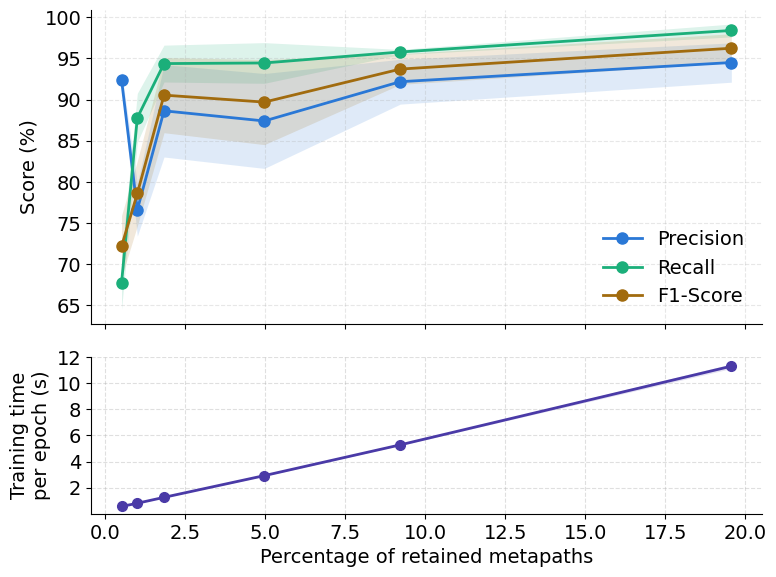

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoLocator, MultipleLocator

# Palette (dataviz skill's validated categorical slots):
#   slot 1 (blue) / slot 2 (aqua) for the two performance lines,
#   slot 5 (violet) for the single-series bar panel — kept out of the
#   line panel's hue range so it doesn't read as a third "performance" series.
COLOR_PRECISION = "#2a78d6"
COLOR_RECALL = "#1baf7a"
COLOR_F1 = "#a16b0e"
COLOR_TIME = "#4a3aa7"

plot_df = comparison_df.sort_values("pct_metapaths")
x = plot_df["pct_metapaths"].to_numpy()

plt.rcParams.update({'font.size': 14})
fig, (ax_perf, ax_time) = plt.subplots(
    2, 1, figsize=(8, 6), sharex=True, height_ratios=[2, 1]
)

# --- Top panel: accuracy & PR-AUC, mean line + std band ---
for col, color, label in [
    ("precision_macro", COLOR_PRECISION, "Precision"),
    ("recall_macro", COLOR_RECALL, "Recall"),
    ("f1_macro", COLOR_F1, "F1-Score"),
]:
    mean = plot_df[f"{col}_mean"].to_numpy() * 100
    std = plot_df[f"{col}_std"].to_numpy() * 100
    ax_perf.plot(x * 100, mean, color=color, linewidth=2, marker="o", markersize=8, label=label)
    ax_perf.fill_between(x * 100, mean - std, mean + std, color=color, alpha=0.15, linewidth=0)

ax_perf.set_ylabel("Score (%)")
ax_perf.legend(frameon=False)
ax_perf.grid(axis="x", linestyle="--", alpha=0.3)
ax_perf.grid(axis="y", linestyle="--", alpha=0.3)
ax_perf.spines[["top", "right"]].set_visible(False)
ax_perf.yaxis.set_major_locator(MultipleLocator(5))

# --- Bottom panel: epoch training time, bars + std error bars ---
# bar width as a fraction of x so bars read consistently on a log x-axis
widths = x * 0.15
ax_time.plot(
    x * 100, plot_df["epoch_time_mean"],
    color=COLOR_TIME, marker="o", linewidth=2, markersize=7,
)
ax_time.fill_between(x * 100, plot_df["epoch_time_mean"] - plot_df["epoch_time_std"], plot_df["epoch_time_mean"] + plot_df["epoch_time_std"], color=COLOR_TIME, alpha=0.15, linewidth=0)
ax_time.set_ylabel("Training time\nper epoch (s)")
ax_time.set_xlabel("Percentage of retained metapaths")
#ax_time.set_xscale("log")

#ax_time.xaxis.set_major_locator(FixedLocator(x * 100))
#ax_time.xaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{v:.1f}'))
ax_time.xaxis.set_major_locator(MultipleLocator(2.5))
ax_time.yaxis.set_major_locator(MultipleLocator(2))
ax_time.grid(True, axis="both", linestyle="--", alpha=0.4)
ax_time.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()


# CCTX Dataset

In [16]:
df2 = load_data("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-cctx-internaltx-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/dme_report.csv")
df2["abs_difference"] = df2["difference"].abs()

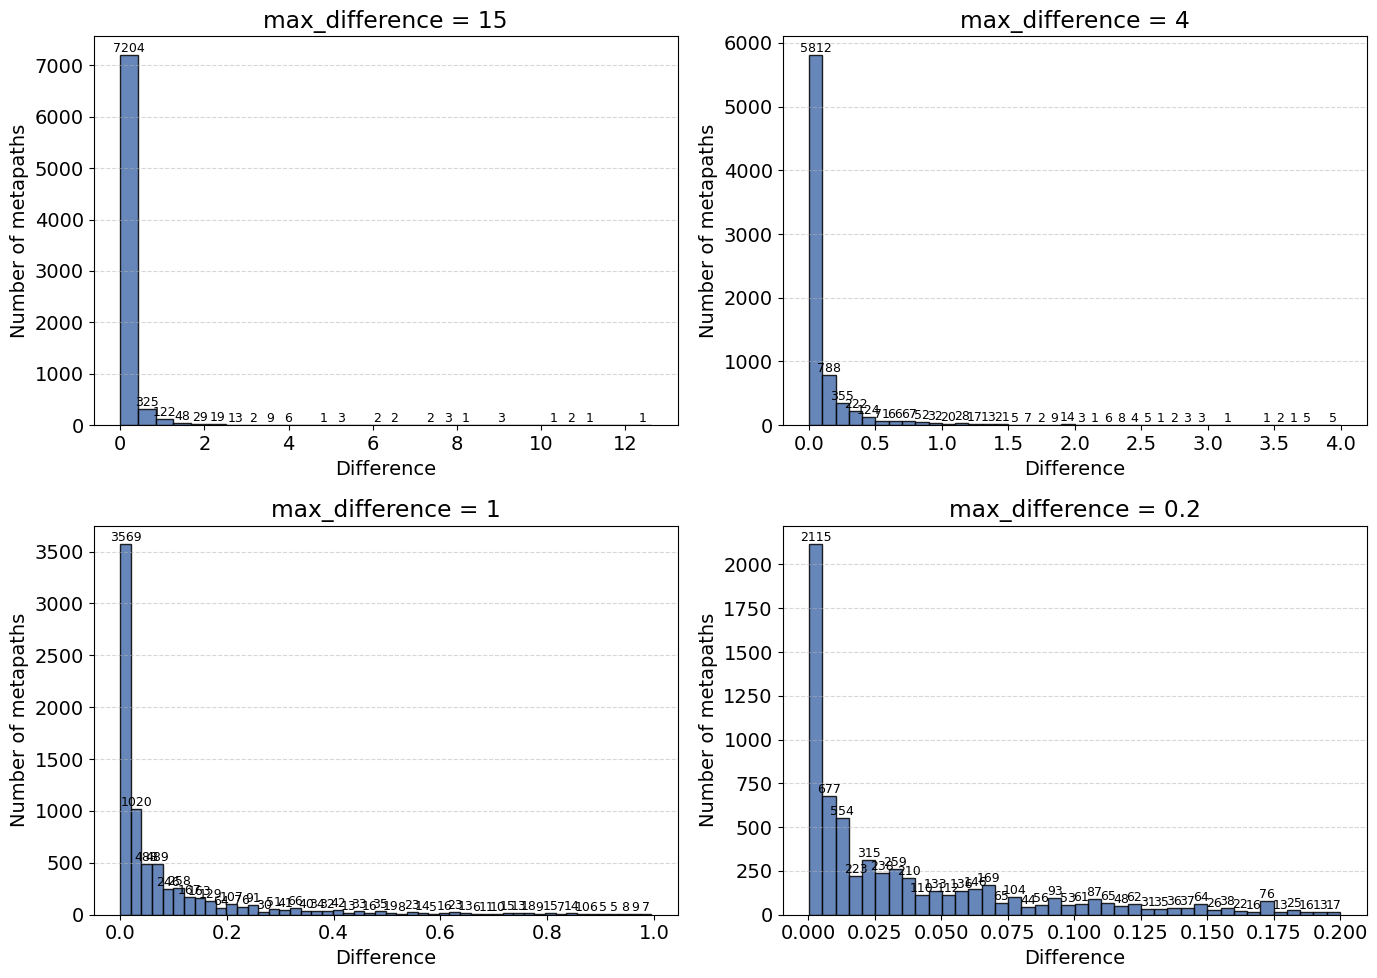

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
plot_histogram(df2, 50, 15, ax=ax, ax_index=0, interval_size=0.5)
plot_histogram(df2, 50, 4, ax=ax, ax_index=1, interval_size=0.1)
plot_histogram(df2, 50, 1, ax=ax, ax_index=2, interval_size=0.02)
plot_histogram(df2, 50, 0.2, ax=ax, ax_index=3, interval_size=0.005)
plt.tight_layout()

<module 'matplotlib.pyplot' from '/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/.venv/lib/python3.14/site-packages/matplotlib/pyplot.py'>

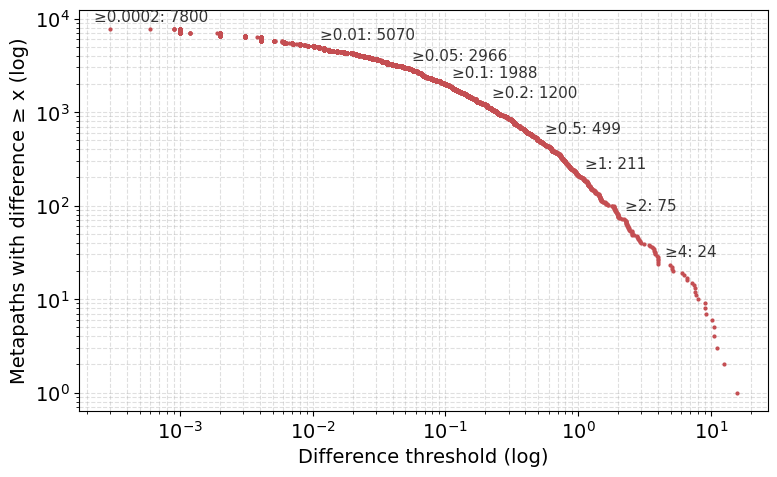

In [18]:
thresholds = [0.0002, 0.01, 0.05, 0.1, 0.2, 0.5, 1, 2, 4]
plt = plot_ccdf({
    "Cross-chain": df2,
}, thresholds)
plt

<module 'matplotlib.pyplot' from '/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/.venv/lib/python3.14/site-packages/matplotlib/pyplot.py'>

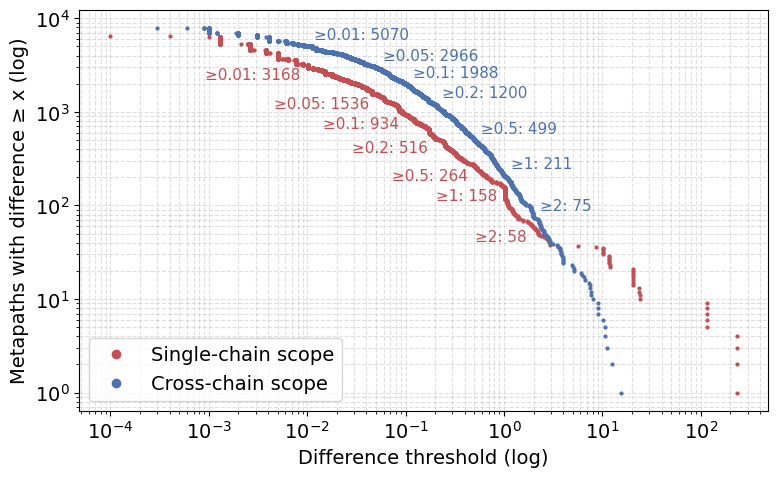

In [19]:
thresholds = [0.01, 0.05, 0.1, 0.2, 0.5, 1, 2]
plt = plot_ccdf({
    "Single-chain scope": df,
    "Cross-chain scope": df2,
}, thresholds)
plt

In [20]:
def min_threshold_for_percentage(df: pd.DataFrame, percentage: float, column: str = "difference") -> float:
    """
    Find the minimum 'difference' threshold t such that at least
    `percentage`% of the metapaths in df have difference >= t.
 
    In other words: what's the lowest bar I can set such that
    `percentage`% of the data still clears it?
 
    Parameters
    ----------
    df : pd.DataFrame
        Must contain the given `column` (default 'difference').
    percentage : float
        Target percentage of metapaths to retain, in (0, 100].
        e.g. 90 -> threshold below which 90% of metapaths remain (difference >= t).
    column : str
        Name of the numeric column to threshold on.
 
    Returns
    -------
    float
        The threshold value t.
    """
    if not (0 < percentage <= 100):
        raise ValueError("percentage must be in the range (0, 100]")
 
    values = df[column].dropna().to_numpy()
    if len(values) == 0:
        raise ValueError(f"No valid values found in column '{column}'")
 
    # We want: count(values >= t) / n >= percentage / 100
    # Equivalently: t is the (100 - percentage)-th percentile of the data,
    # using the "lower" interpolation so the guarantee (>= t) is not violated
    # by interpolated values that don't actually exist in the dataset.
    quantile_point = (100 - percentage) / 100
    threshold = np.quantile(values, quantile_point, method="lower")
 
    return float(threshold)
 
 
def thresholds_for_percentages(df: pd.DataFrame, percentages, column: str = "abs_difference") -> pd.DataFrame:
    """
    Convenience wrapper: compute thresholds for a list of percentages at once.
 
    Returns a DataFrame with columns: percentage, threshold, n_metapaths_retained
    """
    values = df[column].dropna().to_numpy()
    n_total = len(values)
 
    rows = []
    for p in percentages:
        t = min_threshold_for_percentage(df, p, column)
        n_retained = int((values >= t).sum())
        rows.append({
            "percentage": p,
            "threshold": t,
            "n_metapaths_retained": n_retained,
            "pct_actually_retained": round(100 * n_retained / n_total, 2),
        })
 
    return pd.DataFrame(rows)

thresholds_for_percentages(df2, [100, 50, 20, 10, 5, 2, 1, 0.5])

,percentage,threshold,n_metapaths_retained,pct_actually_retained
0,100.0,0.0003,7800,100.00
1,50.0,0.0254,3916,50.21
2,20.0,0.1404,1563,20.04
3,10.0,0.3266,790,10.13
4,5.0,0.6409,391,5.01
5,2.0,1.2350,157,2.01
6,1.0,1.9939,81,1.04
7,0.5,2.9705,40,0.51


## Evaluation Runs

In [21]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from types import SimpleNamespace

from cli import Cli
from dataset_generator.types import DATASET_TYPE

# Define the absolute path for the root directory for outputs here (and if possible, make sure to have a prepared _dataset folder)
OUTPUTS_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-cctx-internaltx-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge")

The next cells will run the model training for different metapath difference thresholds.

This process can take a long time to finish.

**If you already have the models trained, you can skip this section and go to the evaluation section.**

In [122]:
dataset_path = OUTPUTS_ROOT.absolute() / "_dataset"
fixed_args = {
    "device": "cpu",  # Change to "cuda" if you have a GPU and want to use it
    "dataset": DATASET_TYPE.CCTX,
    "load_data": str(dataset_path),
    "new_dataset": None,
    "force_reload": False,
    "num_workers": 0,
    "tags": "deepsad,tuningdme",

    "num_epochs": 100,
    # Notice that, for the CCTX scope in the new approach, 
    # the learning rate needs to be lowered
    "learning_rate": 0.002, 
    "augment_factor": 0,
    "rm_semantic_fusion": True,
    "early_stopping": 15,
    "kfolds": 5,
    "first_layer_channels": 128,
    "hidden_channels": 64,
    "dropout": 0.5,
    "input_drop": 0.0,
    "att_drop": 0.0,
    "n_fp_layers": 2,
    "n_mlp_layers": 2,
    "activation": "relu",
    "pooling": "mean",
    "residual": False,
    "random_seed": 42,
    "test_split": 0.15,
    "rep_dim": 64,
    "eta": 1.0,
    "deep_sad_eps": 1.0,
    "grad_clip": 1.0,
    "weight_decay": 1e-6,
    "ae_pretrain": False,
}

In [ ]:
# Run for 0.5%
dme_val = min_threshold_for_percentage(df2, 0.5, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [ ]:
# Run for 1%
dme_val = min_threshold_for_percentage(df2, 1, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [ ]:
# Run for 2%
dme_val = min_threshold_for_percentage(df2, 2, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [ ]:
# Run for 5%
dme_val = min_threshold_for_percentage(df2, 5, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [ ]:
# Run for 10%
dme_val = min_threshold_for_percentage(df2, 10, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [123]:
# Run for 20%
dme_val = min_threshold_for_percentage(df2, 20, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

Early stopping: 15
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 983 normal, 71 anomaly.
Identified 1549 differential meta-paths for training.
Fold 1: centre initialised from 786 normal graphs.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 2.4208, val loss: 0.5140, PR-AUC (anomaly): 0.0647, f2-score (anomaly): 0.2767, tau: 8.8142e-02
  dist(normal) 5.0129e-01+-1.3269e+00 | dist(anomaly) 1.8826e-01+-1.5050e-01
              precision    recall  f1-score   support

           0       1.00      0.07      0.13       197
           1       0.07      1.00      0.13        14

    accuracy                           0.13       211
   macro avg       0.54      0.54      0.13       211
weighted avg       0.94      0.13      0.13       211

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.6908, val loss: 0.2096, PR-

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-internaltx-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.002_dme0.1404_nosf_es15_deepsad_tuningdme__202608091641'

## Results processing

**NOTE:** Make sure to run the OUTPUTS_ROOT cell first (available in the section above) to set the correct path to the outputs directory.

In [31]:
# Obtain all relevant run directories that match the pattern and contain a params.yaml file
run_dirs = sorted(
    p for p in OUTPUTS_ROOT.glob("train_epochs100_augment0_lr0.002_dme*")
    if p.is_dir() and (p / "params.yaml").exists()
)

print(f"Found {len(run_dirs)} run directories")
for p in run_dirs:
    print(p)

Found 6 run directories
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-cctx-internaltx-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.002_dme0.1404_nosf_es15_deepsad_tuningdme__202608091641
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-cctx-internaltx-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.002_dme0.3266_nosf_es15_deepsadbased_tuningdme__202608061902
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-cctx-internaltx-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.002_dme0.6409_nosf_es15_deepsadbased_tuningdme__202608061842
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/deepsad-cctx-internaltx-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100

In [32]:
import yaml

def load_run_config(run_dir: Path) -> dict:
    TOTAL_METAPATHS = 6475  # Total number of metapaths in the dataset
    with open(run_dir / "params.yaml") as f:
        doc = yaml.safe_load(f)

    return {
        "run_dir": run_dir,
        "run_name": run_dir.name,
        "dme_threshold": doc["dme"]["dme_threshold"],
        "reported_metapaths": doc["dme"]["reported_metapaths"],
        "pct_metapaths": doc["dme"]["reported_metapaths"] / TOTAL_METAPATHS,
        "total_samples": doc["dataset"]["stats"]["total_samples"],
        "anomaly_ratio": doc["dataset"]["stats"]["anomaly_ratio"],
    }

configs = [load_run_config(p) for p in run_dirs]
configs_df = pd.DataFrame(configs)
configs_df

,run_dir,run_name,dme_threshold,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme0.1404_nos...,0.1404,1549,0.239228,1241,0.0677
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme0.3266_nos...,0.3266,769,0.118764,1241,0.0677
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme0.6409_nos...,0.6409,381,0.058842,1241,0.0677
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme1.235_nosf...,1.2350,156,0.024093,1241,0.0677
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme1.9939_nos...,1.9939,75,0.011583,1241,0.0677
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme2.9705_nos...,2.9705,39,0.006023,1241,0.0677


In [33]:
def load_val_metrics(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "val_best_metrics.csv")
    metric_cols = [c for c in df.columns if c != "fold"]

    result = {"run_dir": run_dir}
    for col in metric_cols:
        result[f"{col}_mean"] = df[col].mean()
        result[f"{col}_std"] = df[col].std(ddof=0)

    result["precision_macro_mean"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).mean()
    result["precision_macro_std"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).std(ddof=0)
    result["recall_macro_mean"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).mean()
    result["recall_macro_std"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).std(ddof=0)
    result["f1_macro_mean"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).mean()
    result["f1_macro_std"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).std(ddof=0)
    return result

metrics = [load_val_metrics(p) for p in run_dirs]
metrics_df = pd.DataFrame(metrics)
metrics_df

,run_dir,epoch_mean,epoch_std,val_loss_mean,val_loss_std,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,...,mcc_mean,mcc_std,threshold_mean,threshold_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,25.4,6.651316,0.062319,0.036049,0.994308,0.006965,0.997975,0.002481,0.995918,...,0.960355,0.044038,11.746931,19.517557,0.977935,0.041614,0.983673,0.016263,0.979289,0.023374
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,21.6,9.520504,1.507555,2.979877,0.996204,0.003548,0.997970,0.002487,0.997964,...,0.970089,0.028490,30.330202,58.153860,0.985592,0.016783,0.984696,0.017744,0.984910,0.014279
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,33.2,19.933891,0.097740,0.092601,0.931745,0.103681,0.989435,0.008564,0.936015,...,0.750516,0.262829,0.746104,1.095192,0.856141,0.153082,0.904674,0.093454,0.859474,0.160630
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,28.0,20.464604,0.047064,0.013775,0.868219,0.134008,0.980918,0.013676,0.876121,...,0.584508,0.274591,0.070084,0.069002,0.798738,0.188723,0.820918,0.105045,0.748029,0.178451
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,35.6,25.192062,0.059032,0.016632,0.882401,0.111940,0.991644,0.005320,0.880840,...,0.627482,0.255835,0.172555,0.335530,0.765419,0.158272,0.890896,0.074435,0.776673,0.165723
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,3.4,2.332381,0.559361,0.018470,0.218267,0.039083,1.000000,0.000000,0.161825,...,0.112817,0.017651,0.549010,0.181979,0.539760,0.002308,0.580913,0.020710,0.211834,0.034402


In [34]:
def load_fold_durations(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "fold_durations.csv")

    # Early stopping means folds can run for different numbers of epochs,
    # so raw fold time alone is not comparable across runs/folds.
    loss_df = pd.read_csv(run_dir / "val_val_loss.csv")
    fold_cols = [c for c in loss_df.columns if c.startswith("fold_")]
    epochs_per_fold = loss_df[fold_cols].notna().sum()

    df["epochs"] = df["fold"].map(epochs_per_fold)
    df["time_per_epoch"] = df["time"] / df["epochs"]

    return {
        "run_dir": run_dir,
        "fold_time_mean": df["time"].mean(),
        "fold_time_std": df["time"].std(ddof=0),  # match summary.txt convention
        "fold_time_total": df["time"].sum(),
        "epoch_time_mean": df["time_per_epoch"].mean(),
        "epoch_time_std": df["time_per_epoch"].std(ddof=0),
    }

durations = [load_fold_durations(p) for p in run_dirs]
durations_df = pd.DataFrame(durations)
durations_df

,run_dir,fold_time_mean,fold_time_std,fold_time_total,epoch_time_mean,epoch_time_std
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,714.606,146.094481,3573.03,20.540576,0.128296
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,357.562,89.138195,1787.81,10.144596,0.292516
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,227.790,85.826395,1138.95,5.181940,0.136223
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,94.814,47.467246,474.07,2.275593,0.043824
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,67.110,29.771030,335.55,1.408802,0.039344
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,16.510,2.234636,82.55,0.896513,0.018322


In [35]:
comparison_df = (
    configs_df
    .merge(metrics_df, on="run_dir")
    .merge(durations_df, on="run_dir")
    .sort_values(["dme_threshold"])
    .reset_index(drop=True)
)
comparison_df

,run_dir,run_name,dme_threshold,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio,epoch_mean,epoch_std,val_loss_mean,...,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,fold_time_mean,fold_time_std,fold_time_total,epoch_time_mean,epoch_time_std
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme0.1404_nos...,0.1404,1549,0.239228,1241,0.0677,25.4,6.651316,0.062319,...,0.041614,0.983673,0.016263,0.979289,0.023374,714.606,146.094481,3573.03,20.540576,0.128296
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme0.3266_nos...,0.3266,769,0.118764,1241,0.0677,21.6,9.520504,1.507555,...,0.016783,0.984696,0.017744,0.984910,0.014279,357.562,89.138195,1787.81,10.144596,0.292516
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme0.6409_nos...,0.6409,381,0.058842,1241,0.0677,33.2,19.933891,0.097740,...,0.153082,0.904674,0.093454,0.859474,0.160630,227.790,85.826395,1138.95,5.181940,0.136223
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme1.235_nosf...,1.2350,156,0.024093,1241,0.0677,28.0,20.464604,0.047064,...,0.188723,0.820918,0.105045,0.748029,0.178451,94.814,47.467246,474.07,2.275593,0.043824
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme1.9939_nos...,1.9939,75,0.011583,1241,0.0677,35.6,25.192062,0.059032,...,0.158272,0.890896,0.074435,0.776673,0.165723,67.110,29.771030,335.55,1.408802,0.039344
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme2.9705_nos...,2.9705,39,0.006023,1241,0.0677,3.4,2.332381,0.559361,...,0.002308,0.580913,0.020710,0.211834,0.034402,16.510,2.234636,82.55,0.896513,0.018322


In [36]:
trimmed_df = comparison_df[[
    "pct_metapaths", 
    "reported_metapaths",
    "dme_threshold",
    "accuracy_mean",
    "accuracy_std",
    "precision_normal_mean",
    "precision_normal_std",
    "recall_normal_mean",
    "recall_normal_std",
    "f1_normal_mean",
    "f1_normal_std",
    "precision_anomaly_mean",
    "precision_anomaly_std",
    "recall_anomaly_mean",
    "recall_anomaly_std",
    "f1_anomaly_mean",
    "f1_anomaly_std",
    "f2_anomaly_mean",
    "f2_anomaly_std",
    "pr_auc_mean",
    "pr_auc_std",
    "epoch_time_mean",
    "epoch_time_std",
]]
trimmed_df

,pct_metapaths,reported_metapaths,dme_threshold,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,...,recall_anomaly_mean,recall_anomaly_std,f1_anomaly_mean,f1_anomaly_std,f2_anomaly_mean,f2_anomaly_std,pr_auc_mean,pr_auc_std,epoch_time_mean,epoch_time_std
0,0.239228,1549,0.1404,0.994308,0.006965,0.997975,0.002481,0.995918,0.008163,0.996923,...,0.971429,0.034993,0.961656,0.042972,0.966685,0.027333,0.973970,0.024740,20.540576,0.128296
1,0.118764,769,0.3266,0.996204,0.003548,0.997970,0.002487,0.997964,0.002493,0.997964,...,0.971429,0.034993,0.971855,0.026660,0.971489,0.030237,0.944933,0.085491,10.144596,0.292516
2,0.058842,381,0.6409,0.931745,0.103681,0.989435,0.008564,0.936015,0.105377,0.959118,...,0.873333,0.083059,0.759831,0.257746,0.804367,0.196813,0.782631,0.246619,5.181940,0.136223
3,0.024093,156,1.2350,0.868219,0.134008,0.980918,0.013676,0.876121,0.146460,0.918709,...,0.765714,0.188355,0.577348,0.276716,0.629158,0.216242,0.575787,0.261365,2.275593,0.043824
4,0.011583,75,1.9939,0.882401,0.111940,0.991644,0.005320,0.880840,0.118793,0.928734,...,0.900952,0.057649,0.624613,0.263793,0.733679,0.184135,0.569421,0.299535,1.408802,0.039344
5,0.006023,39,2.9705,0.218267,0.039083,1.000000,0.000000,0.161825,0.041420,0.276376,...,1.000000,0.000000,0.147291,0.007925,0.301466,0.013300,0.078814,0.005568,0.896513,0.018322


In [37]:
PCT_SCALE_EXCLUDE = {"epoch_time"}  # keep seconds as seconds, not *100

def format_stat(mean, std, base):
    scale = 1 if base in PCT_SCALE_EXCLUDE else 100
    return f"{mean * scale:.2f} \u00b1 {std * scale:05.2f}"

metric_bases = [c[:-5] for c in trimmed_df.columns if c.endswith("_mean")]

display_df = pd.DataFrame(index=trimmed_df.index)
display_df["reported_metapaths"] = trimmed_df["reported_metapaths"].map(lambda v: f"{v:.0f}")
display_df["dme_threshold"] = trimmed_df["dme_threshold"].map(lambda v: f"{v:.4f}")
for base in metric_bases:
    display_df[base] = trimmed_df.apply(
        lambda row: format_stat(row[f"{base}_mean"], row[f"{base}_std"], base), axis=1
    )

display_df.insert(0, "pct_metapaths", (trimmed_df["pct_metapaths"]*100).map(lambda v: f"{v:.2f}%"))
display_df = display_df.set_index("pct_metapaths")

final_table = display_df.T
final_table


pct_metapaths,23.92%,11.88%,5.88%,2.41%,1.16%,0.60%
reported_metapaths,1549,769,381,156,75,39
dme_threshold,0.1404,0.3266,0.6409,1.2350,1.9939,2.9705
accuracy,99.43 ± 00.70,99.62 ± 00.35,93.17 ± 10.37,86.82 ± 13.40,88.24 ± 11.19,21.83 ± 03.91
precision_normal,99.80 ± 00.25,99.80 ± 00.25,98.94 ± 00.86,98.09 ± 01.37,99.16 ± 00.53,100.00 ± 00.00
recall_normal,99.59 ± 00.82,99.80 ± 00.25,93.60 ± 10.54,87.61 ± 14.65,88.08 ± 11.88,16.18 ± 04.14
f1_normal,99.69 ± 00.38,99.80 ± 00.19,95.91 ± 06.40,91.87 ± 08.59,92.87 ± 07.05,27.64 ± 06.16
precision_anomaly,95.79 ± 08.42,97.32 ± 03.29,72.28 ± 29.79,61.66 ± 37.91,53.92 ± 31.31,7.95 ± 00.46
recall_anomaly,97.14 ± 03.50,97.14 ± 03.50,87.33 ± 08.31,76.57 ± 18.84,90.10 ± 05.76,100.00 ± 00.00
f1_anomaly,96.17 ± 04.30,97.19 ± 02.67,75.98 ± 25.77,57.73 ± 27.67,62.46 ± 26.38,14.73 ± 00.79
f2_anomaly,96.67 ± 02.73,97.15 ± 03.02,80.44 ± 19.68,62.92 ± 21.62,73.37 ± 18.41,30.15 ± 01.33


In [38]:
# Turn the unicode ± into LaTeX math syntax, and escape underscores in row labels
import re

METRIC_LABELS = {
    "reported_metapaths": "Reported Metapaths",
    "dme_threshold": "DME Threshold",
    "test_loss": "Test Loss (\\%)",
    "accuracy": "Accuracy (\\%)",
    "precision_normal": "Precision (Normal) (\\%)",
    "recall_normal": "Recall (Normal) (\\%)",
    "f1_normal": "F1 (Normal) (\\%)",
    "precision_anomaly": "Precision (Anomaly) (\\%)",
    "recall_anomaly": "Recall (Anomaly) (\\%)",
    "f1_anomaly": "F1 (Anomaly) (\\%)",
    "f2_anomaly": "F2 (Anomaly) (\\%)",
    "pr_auc": "PR-AUC (\\%)",
    "epoch_time": "Epoch Training Time (sec/epoch)",
}

def to_math_pm(s: str) -> str:
    return re.sub(r"(-?[\d.]+) \u00b1 (-?[\d.]+)", r"$\1 \\pm \2$", s)

latex_ready = final_table.map(to_math_pm)
latex_ready = latex_ready.rename(index=METRIC_LABELS)
latex_ready.index = latex_ready.index.str.replace("_", r"\_", regex=False)

latex_str = latex_ready.to_latex(
    escape=False,  # cell values already contain LaTeX ($\pm$), don't double-escape
    column_format="l" + "c" * len(latex_ready.columns),
    caption="Effect of the DME threshold on test-set performance",
    label="tab:dme_threshold_comparison",
)
print(latex_str)

with open("dme_threshold_comparison.tex", "w") as f:
    f.write(latex_str)


\begin{table}
\caption{Effect of the DME threshold on test-set performance}
\label{tab:dme_threshold_comparison}
\begin{tabular}{lcccccc}
\toprule
pct_metapaths & 23.92% & 11.88% & 5.88% & 2.41% & 1.16% & 0.60% \\
\midrule
Reported Metapaths & 1549 & 769 & 381 & 156 & 75 & 39 \\
DME Threshold & 0.1404 & 0.3266 & 0.6409 & 1.2350 & 1.9939 & 2.9705 \\
Accuracy (\%) & $99.43 \pm 00.70$ & $99.62 \pm 00.35$ & $93.17 \pm 10.37$ & $86.82 \pm 13.40$ & $88.24 \pm 11.19$ & $21.83 \pm 03.91$ \\
Precision (Normal) (\%) & $99.80 \pm 00.25$ & $99.80 \pm 00.25$ & $98.94 \pm 00.86$ & $98.09 \pm 01.37$ & $99.16 \pm 00.53$ & $100.00 \pm 00.00$ \\
Recall (Normal) (\%) & $99.59 \pm 00.82$ & $99.80 \pm 00.25$ & $93.60 \pm 10.54$ & $87.61 \pm 14.65$ & $88.08 \pm 11.88$ & $16.18 \pm 04.14$ \\
F1 (Normal) (\%) & $99.69 \pm 00.38$ & $99.80 \pm 00.19$ & $95.91 \pm 06.40$ & $91.87 \pm 08.59$ & $92.87 \pm 07.05$ & $27.64 \pm 06.16$ \\
Precision (Anomaly) (\%) & $95.79 \pm 08.42$ & $97.32 \pm 03.29$ & $72.28 \pm 29

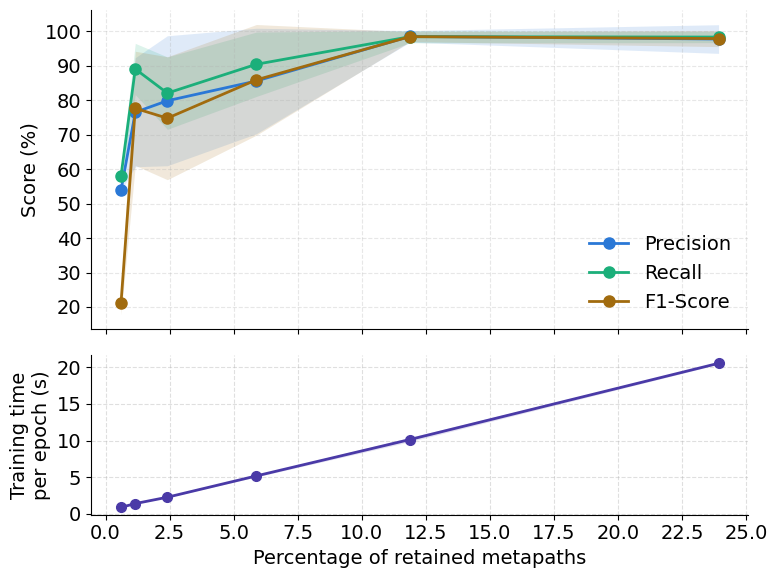

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoLocator, MultipleLocator

# Palette (dataviz skill's validated categorical slots):
#   slot 1 (blue) / slot 2 (aqua) for the two performance lines,
#   slot 5 (violet) for the single-series bar panel — kept out of the
#   line panel's hue range so it doesn't read as a third "performance" series.
COLOR_PRECISION = "#2a78d6"
COLOR_RECALL = "#1baf7a"
COLOR_F1 = "#a16b0e"
COLOR_TIME = "#4a3aa7"

plot_df = comparison_df.sort_values("pct_metapaths")
x = plot_df["pct_metapaths"].to_numpy()

plt.rcParams.update({'font.size': 14})
fig, (ax_perf, ax_time) = plt.subplots(
    2, 1, figsize=(8, 6), sharex=True, height_ratios=[2, 1]
)

# --- Top panel: accuracy & PR-AUC, mean line + std band ---
for col, color, label in [
    ("precision_macro", COLOR_PRECISION, "Precision"),
    ("recall_macro", COLOR_RECALL, "Recall"),
    ("f1_macro", COLOR_F1, "F1-Score"),
]:
    mean = plot_df[f"{col}_mean"].to_numpy() * 100
    std = plot_df[f"{col}_std"].to_numpy() * 100
    ax_perf.plot(x * 100, mean, color=color, linewidth=2, marker="o", markersize=8, label=label)
    ax_perf.fill_between(x * 100, mean - std, mean + std, color=color, alpha=0.15, linewidth=0)

ax_perf.set_ylabel("Score (%)")
ax_perf.legend(frameon=False)
ax_perf.grid(axis="x", linestyle="--", alpha=0.3)
ax_perf.grid(axis="y", linestyle="--", alpha=0.3)
ax_perf.spines[["top", "right"]].set_visible(False)
ax_perf.yaxis.set_major_locator(MultipleLocator(10))

# --- Bottom panel: epoch training time, bars + std error bars ---
# bar width as a fraction of x so bars read consistently on a log x-axis
widths = x * 0.15
ax_time.plot(
    x * 100, plot_df["epoch_time_mean"],
    color=COLOR_TIME, marker="o", linewidth=2, markersize=7,
)
ax_time.fill_between(x * 100, plot_df["epoch_time_mean"] - plot_df["epoch_time_std"], plot_df["epoch_time_mean"] + plot_df["epoch_time_std"], color=COLOR_TIME, alpha=0.15, linewidth=0)
ax_time.set_ylabel("Training time\nper epoch (s)")
ax_time.set_xlabel("Percentage of retained metapaths")
#ax_time.set_xscale("log")

#ax_time.xaxis.set_major_locator(FixedLocator(x * 100))
#ax_time.xaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{v:.1f}'))
ax_time.xaxis.set_major_locator(MultipleLocator(2.5))
ax_time.yaxis.set_major_locator(MultipleLocator(5))
ax_time.grid(True, axis="both", linestyle="--", alpha=0.4)
ax_time.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()
